In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [2]:
def make_cos_phi_operator(N):
    """
    Constructs the cos(φ) operator in the charge basis for a given cutoff N.
    
    Parameters:
    N (int): The cutoff for the charge basis, resulting in a (2N+1)x(2N+1) matrix.
    
    Returns:
    Qobj: The cos(φ) operator as a QuTiP quantum object.
    """
    dim = 2 * N + 1
    cos_phi_np = np.zeros((dim, dim), dtype=complex)

    for n in range(-N, N + 1): # loops from -N to N inclusive
        if n + 1 <= N:
            cos_phi_np[n + N, n + 1 + N] = 0.5
        if n - 1 >= -N:
            cos_phi_np[n + N, n - 1 + N] = 0.5
    
    return qt.Qobj(cos_phi_np, dims=[[dim], [dim]])

def make_Hamiltonian(Ec, Ej, ng, N):
    """
    Constructs the Hamiltonian for a Cooper pair box in the charge basis.
    
    Parameters:
    Ec (float): Charging energy.
    Ej (float): Josephson energy.
    ng (float): Offset charge.
    N (int): Cutoff for the charge basis.
    
    Returns:
    Qobj: The Hamiltonian as a QuTiP quantum object.
    """
    dim = 2 * N + 1
    charge_op = qt.Qobj(np.diag(np.arange(-N, N + 1)), dims=[[dim], [dim]])
    I = qt.qeye(dim)
    cos_phi_op = make_cos_phi_operator(N)
    
    H = 4 * Ec * (charge_op - ng * I)**2 - Ej * cos_phi_op
    return H

# C (i)

In [3]:
Ec = 10 # Charging energy
Ej = 1 # Josephson energy
ng = 0.5 # Offset charge
N = 10 # Cutoff for charge basis

# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
print(f"E01 = {eigenvalues[1] - eigenvalues[0]}")

E01 = 0.9999609393650566


# C (ii)

In [4]:
Ec = 10 # Charging energy
Ej = 1.5 # Josephson energy
ng = 0.5 # Offset charge
N = 10 # Cutoff for charge basis

# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
print(f"E01 = {eigenvalues[1] - eigenvalues[0]}")

E01 = 1.499868178226123


# C (iii)

In [5]:
ng = 0 # Offset charge
N = 10 # Cutoff for charge basis

Ec = 10 # Charging energy
Ej = 0.1 # Josephson energy

# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
print(f"E01 = {eigenvalues[1] - eigenvalues[0]}")

Ec = 11 # Charging energy
Ej = 1 # Josephson energy

# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
print(f"E01 = {eigenvalues[1] - eigenvalues[0]}")

E01 = 40.000104166327205
E01 = 44.00946714720328


# C (iv)

In [6]:
Ec = 10 # Charging energy
Ej = 1 # Josephson energy

ng = 0.5
# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
E01_initial = eigenvalues[1] - eigenvalues[0]
print(f"E01 = {E01_initial}")

ng = 0.55
# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
E01_final = eigenvalues[1] - eigenvalues[0]
print(f"E01 = {E01_final}")
print(f"Change in E01: {(E01_final - E01_initial)/E01_initial * 100:.2f}%")

E01 = 0.9999609393650566
E01 = 4.12339993824385
Change in E01: 312.36%


# C (v)

In [7]:
Ec = 10 # Charging energy
Ej = 1 # Josephson energy

ng = 0.5
# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
E01 = eigenvalues[1] - eigenvalues[0]
E12 = eigenvalues[2] - eigenvalues[1]
E02 = eigenvalues[2] - eigenvalues[0]
print(f"E01 = {E01}")
print(f"E12 = {E12}")
print(f"E02 = {E02}")

ng = 0
# Diagonalize the Hamiltonian
eigenvalues, eigenstates = make_Hamiltonian(Ec, Ej, ng, N).eigenstates()
E01 = eigenvalues[1] - eigenvalues[0]
E12 = eigenvalues[2] - eigenvalues[1]
E02 = eigenvalues[2] - eigenvalues[0]
print(f"\nE01 = {E01}")
print(f"E12 = {E12}")
print(f"E02 = {E02}")

E01 = 0.9999609393650566
E12 = 79.50468758035807
E02 = 80.50464851972312

E01 = 40.0104132732683
E12 = 0.012496529743927454
E02 = 40.022909803012226


# d

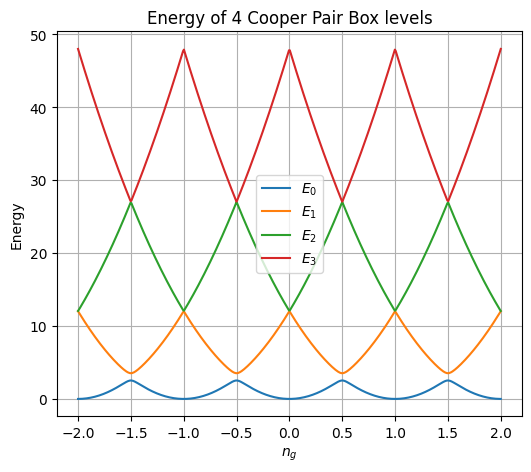

In [8]:
N = 10
Ec = 3
Ej = 1
n_g_values = np.linspace(-2, 2, 500)
num_levels = 4

energies = np.zeros((len(n_g_values), num_levels))

for idx, ng in enumerate(n_g_values):
    evals = make_Hamiltonian(Ec, Ej, ng, N).eigenenergies()
    energies[idx, :] = evals[:num_levels]

# Plotting the energy levels
plt.figure(figsize=(6, 5))
for i in range(num_levels):
    plt.plot(n_g_values, energies[:, i], label=f"$E_{i}$")
plt.xlabel('$n_g$')
plt.ylabel('Energy')
plt.title(f'Energy of {4} Cooper Pair Box levels')
plt.legend()
plt.grid()
plt.show()

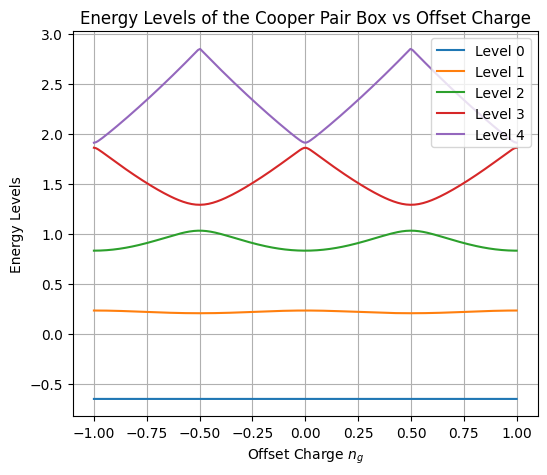

In [10]:
N = 10
omega_plasma = 1
Ej_over_Ec = 10

n_g_values = np.linspace(-1, 1, 200)

energies = np.zeros((len(n_g_values), 5))

for idx, ng in enumerate(n_g_values):
    Ec = omega_plasma / np.sqrt(8 * Ej_over_Ec)
    Ej = Ej_over_Ec * Ec 
    evals = make_Hamiltonian(Ec, Ej, ng, N).eigenenergies()
    energies[idx, :] = evals[:5]

# Plotting the energy levels
plt.figure(figsize=(6, 5))
for i in range(5):
    plt.plot(n_g_values, energies[:, i], label=f'Level {i}')
plt.xlabel('Offset Charge $n_g$')
plt.ylabel('Energy Levels')
plt.title('Energy Levels of the Cooper Pair Box vs Offset Charge')
plt.legend()
plt.grid()
plt.show()